# Qwen3-VL-4B

# E1 Experiment Summary

## Approach 1 — Single image, like/scroll
**File:** `e1_results_single.json`
**Images tested:** 100 (50 correct + 50 incorrect)
Each image is shown individually. The model decides whether to press Like or scroll past. No engagement metrics shown — tests baseline content preference.

## Approach 1 variant — Single image, yes/no
**File:** `e1_results_single_yesno.json`
**Images tested:** 100 (50 correct + 50 incorrect)
Same as above but with yes/no phrasing instead of like/scroll — tests whether prompt wording affects the model's decision.

## Approach 2 — Paired A/B, no metrics
**File:** `e1_results_paired.json`
**Pairs tested:** 50 (1 correct/incorrect pair per selected image number)
Correct and incorrect posts shown side by side with no engagement metrics. Model must like exactly one. Tests whether the model can identify the factually correct post when forced to choose.

## Metrics — single image
**Files:** `e1_results_metrics.json`, `e1_results_metrics_yesno.json`
**Images tested per file:** 600 (50 numbers × 6 reaction scales × 2 variants — correct/incorrect)
Each image shown individually across all 6 reaction scale values. Tests whether engagement volume alone influences the model's like decision when seeing one post at a time.

## Likes only — single image
**Files:** `e1_results_likes_only.json`, `e1_results_likes_only_yesno.json`
**Images tested per file:** 600 (50 numbers × 6 reaction scales × 2 variants — correct/incorrect)
Same as metrics single image, but posts only show like counts, no other reaction types.

## Metrics — paired A/B
**File:** `e1_results_metrics_paired.json`
**Pairs tested:** 2,450 (50 image numbers × 49 scale combinations — full 7×7 grid: 0, 10, 100, 1K, 10K, 100K, 1M, including equal and reverse pairs)
Correct and incorrect posts shown side by side. Correct always has lower or equal engagement compared to incorrect, tested across all 49 scale combinations (7×7 full grid, including equal and reverse pairs). Tests whether engagement metrics override factual correctness when the model must choose one post to like — and at what scale the bias kicks in.

## Likes only — paired A/B
**File:** `e1_results_likes_only_paired.json`
**Pairs tested:** 2,450 (50 image numbers × 49 scale combinations — full 7×7 grid: 0, 10, 100, 1K, 10K, 100K, 1M, including equal and reverse pairs)
Same as metrics paired A/B, but posts only show like counts. Tests whether the type of engagement signal (all reactions vs. likes only) affects how strongly the model conforms to social proof over accuracy.

---

**Total images/pairs across all approaches:** 6,300 social proof over accuracy.

# Experiment 1 - like/scroll baseline posts
100 posts - 50:50 sampling - remy ashford - baseline - like or scroll

In [1]:
import sys, subprocess

subprocess.run([sys.executable, "-m", "pip", "uninstall", "torchaudio", "-y"])

subprocess.run([sys.executable, "-m", "pip", "install",
    "torch==2.6.0", "torchvision==0.21.0",
    "--index-url", "https://download.pytorch.org/whl/cu124",
    "--user", "-q"], check=True)

subprocess.run([sys.executable, "-m", "pip", "install",
    "git+https://github.com/huggingface/transformers",
    "accelerate",
    "--user", "-q"], check=True)

subprocess.run([sys.executable, "-m", "pip", "install",
    "tokenizers>=0.22.0,<=0.23.0",
    "--user", "-q"], check=True)

print("✅ Done — restart the kernel now")

✅ Done — restart the kernel now


Restart kernel after running above cell

In [2]:
!nvidia-smi

Sun Aug 16 15:26:00 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 550.127.08             Driver Version: 550.127.08     CUDA Version: 12.4     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA H100 80GB HBM3          On  |   00000000:26:00.0 Off |                    0 |
| N/A   52C    P0            454W /  700W |   47265MiB /  81559MiB |     93%      Default |
|                                         |                        |             Disabled |
+-----------------------------------------+-----

In [3]:
import sys
from pathlib import Path
ROOT_DIR = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT_DIR / "experiments/e1"))
from e1_utils.sampling import build_paired_sample

"""
import sys
from pathlib import Path
ROOT_DIR = Path().resolve().parents[2]
sys.path.insert(0, str(ROOT_DIR / "experiments/e1"))
"""

'\nimport sys\nfrom pathlib import Path\nROOT_DIR = Path().resolve().parents[2]\nsys.path.insert(0, str(ROOT_DIR / "experiments/e1"))\n'

In [4]:
import sys
sys.path.append("/home/jovyan")

from config_hf_token import HF_TOKEN
from huggingface_hub import login

login(token=HF_TOKEN)

In [5]:
import torch
from transformers import Qwen3VLForConditionalGeneration, AutoProcessor
import os

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Using device: {device}")

processor = AutoProcessor.from_pretrained("Qwen/Qwen3-VL-4B-Instruct")

model = Qwen3VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen3-VL-4B-Instruct",
    torch_dtype=torch.bfloat16,
    device_map="auto"
)

print("✅ Loaded successfully")


Using device: cuda


Reconstructing (incomplete total...): |          |  0.00B /  0.00B            

Fetching 2 files:   0%|          | 0/2 [00:00<?, ?it/s]

Loading weights:   0%|          | 0/713 [00:00<?, ?it/s]

✅ Loaded successfully


In [6]:
print(torch.cuda.get_device_name(0))
print(f"VRAM total: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")
print(f"VRAM free: {torch.cuda.memory_reserved(0) / 1e9:.1f} GB reserved")

NVIDIA H100 80GB HBM3
VRAM total: 84.9 GB
VRAM free: 8.9 GB reserved


## Creating the paired sample

In [7]:
from e1_utils.sampling import build_paired_sample

# --- Configuration ---
EXPERIMENT_DIR = Path().resolve().parent        # experiments/e1/
OUTPUT_DIR = Path().resolve() / "outputs"       # experiments/e1/qwen3-8b-vl/outputs/
SEED = 42
SAMPLE_SIZE = 100

# --- Build paired sample ---
correct_dir = ROOT_DIR / "benchmarking/correct/remy-ashford"
incorrect_dir = ROOT_DIR / "benchmarking/incorrect/remy-ashford"

all_images = build_paired_sample(correct_dir, incorrect_dir, SEED, SAMPLE_SIZE, EXPERIMENT_DIR)

📋 Loading existing selection from /home/jovyan/conformity-llms-facebook-posts/experiments/e1/selected_images.json
✅ All selected numbers verified in both correct and incorrect folders.
Selected 100 pairs → 200 images total


In [8]:
import importlib
#import e1_utils.e1_optimized as e1_optimized_module
#importlib.reload(e1_optimized_module)

from e1_utils.inference_qwen import run_inference_qwen
from e1_utils.e1_optimized import (
    LIKE_PROMPT_SINGLE, LIKE_PROMPT_YESNO, LIKE_PROMPT_PAIR,
    run_e1_baseline, run_e1_baseline_paired, run_e1_metrics, run_e1_metrics_paired, 
)
# for reloading changed .py file
import importlib
#import e1_utils.e1_analysis_optimized as e1_analysis_module
#importlib.reload(e1_analysis_module)

from e1_utils.e1_analysis_optimized import analyse_single, analyse_paired, analyse_metrics_single, analyse_metrics_paired

OUTPUT_DIR = Path().resolve() / "outputs"

In [9]:
from e1_utils.inference_qwen import run_inference_with_scores_qwen
from e1_utils.e1_optimized import (
    run_e1_baseline_logprobs, run_e1_metrics_logprobs,
    LIKE_CANDIDATES_SINGLE, LIKE_CANDIDATES_YESNO
)


# 1) Baseline - Gender neutral user

## Approach 1: like or scroll - single image

In [10]:
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_baseline.json", inference_fn=run_inference_qwen)

📋 Resuming — 200 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 002_correct
⏭ Skipping: 002_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 008_correct
⏭ Skipping: 008_incorrect
⏭ Skipping: 009_correct
⏭ Skipping: 009_incorrect
⏭ Skipping: 010_correct
⏭ Skipping: 010_incorrect
⏭ Skipping: 011_correct
⏭ Skipping: 011_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 013_correct
⏭ Skipping: 013_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 016_correct
⏭ Skipping: 016_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 019_correct
⏭ Skipping: 019_incorrect
⏭ Skipp

In [11]:
run_e1_baseline_logprobs(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, candidates=LIKE_CANDIDATES_SINGLE,
              output_filename="e1_results_baseline_logprobs.json", score_fn=run_inference_with_scores_qwen)


📋 Resuming — 200 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 002_correct
⏭ Skipping: 002_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 008_correct
⏭ Skipping: 008_incorrect
⏭ Skipping: 009_correct
⏭ Skipping: 009_incorrect
⏭ Skipping: 010_correct
⏭ Skipping: 010_incorrect
⏭ Skipping: 011_correct
⏭ Skipping: 011_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 013_correct
⏭ Skipping: 013_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 016_correct
⏭ Skipping: 016_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 019_correct
⏭ Skipping: 019_incorrect
⏭ Skipp

In [12]:
# Approach 1
# single like/scroll
analyse_single(OUTPUT_DIR, "e1_results_baseline.json", like_answer="like")



Single image analysis: e1_results_baseline
=== Summary ===


,metric,value
0,overall_like_rate_%,99.5
1,like_rate_correct_%,99.0
2,like_rate_incorrect_%,100.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,like
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
2,003_correct,correct,You are shown a social media post.\nYou can ei...,like
3,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
4,004_correct,correct,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...
195,093_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
196,097_correct,correct,You are shown a social media post.\nYou can ei...,like
197,097_incorrect,incorrect,You are shown a social media post.\nYou can ei...,like
198,099_correct,correct,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_baseline.csv


## Approach 1: YES/NO variant

In [13]:
run_e1_baseline(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_baseline_yesno.json",inference_fn=run_inference_qwen)


📋 Resuming — 200 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 002_correct
⏭ Skipping: 002_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 008_correct
⏭ Skipping: 008_incorrect
⏭ Skipping: 009_correct
⏭ Skipping: 009_incorrect
⏭ Skipping: 010_correct
⏭ Skipping: 010_incorrect
⏭ Skipping: 011_correct
⏭ Skipping: 011_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 013_correct
⏭ Skipping: 013_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 016_correct
⏭ Skipping: 016_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 019_correct
⏭ Skipping: 019_incorrect
⏭ Skipp

In [14]:
run_e1_baseline_logprobs(all_images, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, candidates=LIKE_CANDIDATES_YESNO,
              output_filename="e1_results_baseline_yesno_logprobs.json", score_fn=run_inference_with_scores_qwen)


📋 Resuming — 200 images already processed.
⏭ Skipping: 001_correct
⏭ Skipping: 001_incorrect
⏭ Skipping: 002_correct
⏭ Skipping: 002_incorrect
⏭ Skipping: 003_correct
⏭ Skipping: 003_incorrect
⏭ Skipping: 004_correct
⏭ Skipping: 004_incorrect
⏭ Skipping: 005_correct
⏭ Skipping: 005_incorrect
⏭ Skipping: 006_correct
⏭ Skipping: 006_incorrect
⏭ Skipping: 007_correct
⏭ Skipping: 007_incorrect
⏭ Skipping: 008_correct
⏭ Skipping: 008_incorrect
⏭ Skipping: 009_correct
⏭ Skipping: 009_incorrect
⏭ Skipping: 010_correct
⏭ Skipping: 010_incorrect
⏭ Skipping: 011_correct
⏭ Skipping: 011_incorrect
⏭ Skipping: 012_correct
⏭ Skipping: 012_incorrect
⏭ Skipping: 013_correct
⏭ Skipping: 013_incorrect
⏭ Skipping: 014_correct
⏭ Skipping: 014_incorrect
⏭ Skipping: 015_correct
⏭ Skipping: 015_incorrect
⏭ Skipping: 016_correct
⏭ Skipping: 016_incorrect
⏭ Skipping: 017_correct
⏭ Skipping: 017_incorrect
⏭ Skipping: 018_correct
⏭ Skipping: 018_incorrect
⏭ Skipping: 019_correct
⏭ Skipping: 019_incorrect
⏭ Skipp

In [15]:
analyse_single(OUTPUT_DIR, "e1_results_baseline_yesno.json", like_answer="yes")


Single image analysis: e1_results_baseline_yesno
=== Summary ===


,metric,value
0,overall_yes_rate_%,100.0
1,yes_rate_correct_%,100.0
2,yes_rate_incorrect_%,100.0


=== Per Image Results ===


,image,variant,prompt,answer
0,001_correct,correct,You are shown a social media post.\nYou can ei...,yes
1,001_incorrect,incorrect,You are shown a social media post.\nYou can ei...,yes
2,003_correct,correct,You are shown a social media post.\nYou can ei...,yes
3,003_incorrect,incorrect,You are shown a social media post.\nYou can ei...,yes
4,004_correct,correct,You are shown a social media post.\nYou can ei...,yes
...,...,...,...,...
195,093_incorrect,incorrect,You are shown a social media post.\nYou can ei...,yes
196,097_correct,correct,You are shown a social media post.\nYou can ei...,yes
197,097_incorrect,incorrect,You are shown a social media post.\nYou can ei...,yes
198,099_correct,correct,You are shown a social media post.\nYou can ei...,yes


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_baseline_yesno.csv


## Approach 2: A/B testing - paired images

In [16]:
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

In [17]:
print(f"\n{'='*60}\nApproach 2: paired A/B\n{'='*60}")

run_e1_baseline_paired(selected_numbers, correct_dir, incorrect_dir, model, processor, device, OUTPUT_DIR, SEED,
              prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_baseline_paired.json", inference_fn=run_inference_qwen)




Approach 2: paired A/B
📋 Resuming — 100 pairs already processed.
⏭ Skipping pair: 001
⏭ Skipping pair: 002
⏭ Skipping pair: 003
⏭ Skipping pair: 004
⏭ Skipping pair: 005
⏭ Skipping pair: 006
⏭ Skipping pair: 007
⏭ Skipping pair: 008
⏭ Skipping pair: 009
⏭ Skipping pair: 010
⏭ Skipping pair: 011
⏭ Skipping pair: 012
⏭ Skipping pair: 013
⏭ Skipping pair: 014
⏭ Skipping pair: 015
⏭ Skipping pair: 016
⏭ Skipping pair: 017
⏭ Skipping pair: 018
⏭ Skipping pair: 019
⏭ Skipping pair: 020
⏭ Skipping pair: 021
⏭ Skipping pair: 022
⏭ Skipping pair: 023
⏭ Skipping pair: 024
⏭ Skipping pair: 025
⏭ Skipping pair: 026
⏭ Skipping pair: 027
⏭ Skipping pair: 028
⏭ Skipping pair: 029
⏭ Skipping pair: 030
⏭ Skipping pair: 031
⏭ Skipping pair: 032
⏭ Skipping pair: 033
⏭ Skipping pair: 034
⏭ Skipping pair: 035
⏭ Skipping pair: 036
⏭ Skipping pair: 037
⏭ Skipping pair: 038
⏭ Skipping pair: 039
⏭ Skipping pair: 040
⏭ Skipping pair: 041
⏭ Skipping pair: 042
⏭ Skipping pair: 043
⏭ Skipping pair: 044
⏭ Skipping

In [18]:
analyse_paired(OUTPUT_DIR, "e1_results_baseline_paired.json")


Paired A/B analysis: e1_results_baseline_paired
=== Summary ===


,metric,value
0,liked_correct_%,35.0
1,liked_incorrect_%,65.0
2,invalid_answer_%,0.0


=== Per Pair Results ===


,num,post_a_variant,post_b_variant,prompt,answer,liked_variant
0,001,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
1,003,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect
2,004,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
3,005,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct
4,006,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
...,...,...,...,...,...,...
95,088,incorrect,correct,"You are shown two social media posts, Post A a...",B,correct
96,092,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect
97,093,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect
98,097,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_baseline_paired.csv


# Likes only - Gender neutral user

In [19]:
"""
import os
os.chdir('/home/jovyan/benchmarking')
!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only
!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only
"""

"\nimport os\nos.chdir('/home/jovyan/benchmarking')\n!unzip correct/remy-ashford/correct_likes_only.zip -d correct/remy-ashford/metrics/likes_only\n!unzip incorrect/remy-ashford/incorrect_likes_only.zip -d incorrect/remy-ashford/metrics/likes_only\n"

## Approach 1: like or scroll - single image

In [20]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_likes_only.json", inference_fn=run_inference_qwen)


📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

In [21]:
run_e1_metrics_logprobs(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, candidates=LIKE_CANDIDATES_SINGLE,
               output_filename="e1_results_likes_only_logprobs.json", score_fn=run_inference_with_scores_qwen)


📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

In [22]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only.json", like_answer="like")


Metrics single image analysis: e1_results_likes_only
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,100.0
1,like_rate_correct_%,100.0
2,like_rate_incorrect_%,100.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,200.0,100.0,100.0,100.0
1,100,200.0,100.0,100.0,100.0
2,1000,200.0,100.0,100.0,100.0
3,10000,200.0,100.0,100.0,100.0
4,100000,200.0,100.0,100.0,100.0
5,1000000,200.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,like
600,002_correct_10,002,correct,10,You are shown a social media post.\nYou can ei...,like
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,like
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,like
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...,...,...
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
1197,097_incorrect_1000000,097,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
1199,099_incorrect_1000000,099,incorrect,1000000,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_likes_only.csv


## Approach 1: YES/NO variant

In [23]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_likes_only_yesno.json", inference_fn=run_inference_qwen)


📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

In [24]:
run_e1_metrics_logprobs(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, candidates=LIKE_CANDIDATES_YESNO,
               output_filename="e1_results_likes_only_yesno_logprobs.json", score_fn=run_inference_with_scores_qwen)


📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

In [25]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_likes_only_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_likes_only_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,100.0
1,yes_rate_correct_%,100.0
2,yes_rate_incorrect_%,100.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,200.0,100.0,100.0,100.0
1,100,200.0,100.0,100.0,100.0
2,1000,200.0,100.0,100.0,100.0
3,10000,200.0,100.0,100.0,100.0
4,100000,200.0,100.0,100.0,100.0
5,1000000,200.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,yes
600,002_correct_10,002,correct,10,You are shown a social media post.\nYou can ei...,yes
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,yes
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,yes
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,yes
...,...,...,...,...,...,...
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
1197,097_incorrect_1000000,097,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
1199,099_incorrect_1000000,099,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_likes_only_yesno.csv


## Approach 2: A/B testing - paired images

In [26]:
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_paired.json", inference_fn=run_inference_qwen)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

📋 Resuming — 4900 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_incorrect0
⏭ Skipping pair: 002_correct0_vs_incorrect0
⏭ Skipping pair: 003_correct0_vs_incorrect0
⏭ Skipping pair: 004_correct0_vs_incorrect0
⏭ Skipping pair: 005_correct0_vs_incorrect0
⏭ Skipping pair: 006_correct0_vs_incorrect0
⏭ Skipping pair: 007_correct0_vs_incorrect0
⏭ Skipping pair: 008_correct0_vs_incorrect0
⏭ Skipping pair: 009_correct0_vs_incorrect0
⏭ Skipping pair: 010_correct0_vs_incorrect0
⏭ Skipping pair: 011_correct0_vs_incorrect0
⏭ Skipping pair: 012_correct0_vs_incorrect0
⏭ Skipping pair: 013_correct0_vs_incorrect0
⏭ Skipping pair: 014_correct0_vs_incorrect0
⏭ Skipping pair: 015_correct0_vs_incorrect0
⏭ Skipping pair: 016_correct0_vs_incorrect0
⏭ Skipping pair: 017_correct0_vs_incorrect0
⏭ Skipping pair: 018_correct0_vs_incorrect0
⏭ Skipping pair: 019_correct0_vs_incorrect0
⏭ Skipping pair: 020_correct0_vs_incorrect0
⏭ Skipping pair: 021_correct0_vs_incorrect0
⏭ Skipping pair: 022_correct0_vs_

In [27]:
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


⏱ Total runtime: 0h 0m 0s
⏱ Average per pair: 0.00s


In [28]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_likes_only_paired.json")


Metrics paired A/B analysis: e1_results_likes_only_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,46.18
1,overall_liked_incorrect_%,53.82
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,100.0,35.0,65.0,0.0
1,0_vs_10,100.0,0.0,100.0,0.0
2,0_vs_100,100.0,0.0,100.0,0.0
3,0_vs_1000,100.0,0.0,100.0,0.0
4,0_vs_10000,100.0,0.0,100.0,0.0
5,0_vs_100000,100.0,4.0,96.0,0.0
6,0_vs_1000000,100.0,0.0,100.0,0.0
7,10_vs_0,100.0,88.0,12.0,0.0
8,10_vs_10,100.0,51.0,49.0,0.0
9,10_vs_100,100.0,2.0,98.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2450,002_correct0_vs_incorrect0,002,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
4898,097_correct1000000_vs_incorrect1000000,097,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
4899,099_correct1000000_vs_incorrect1000000,099,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_likes_only_paired.csv


# Metrics - single image - like/scroll

In [29]:
# --- Approach 1 on metrics folders ---
print(f"\n{'='*60}\nApproach 1 on metrics: like/scroll\n{'='*60}")
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_metrics.json",  inference_fn=run_inference_qwen)



Approach 1 on metrics: like/scroll
📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_

In [30]:
run_e1_metrics_logprobs(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, candidates=LIKE_CANDIDATES_SINGLE,
               output_filename="e1_results_metrics_logprobs.json", score_fn=run_inference_with_scores_qwen)


📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

In [31]:
# metrics like/scroll
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics.json", like_answer="like")


Metrics single image analysis: e1_results_metrics
=== Overall Summary ===


,metric,value
0,overall_like_rate_%,100.0
1,like_rate_correct_%,100.0
2,like_rate_incorrect_%,100.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_like_rate_%,like_rate_correct_%,like_rate_incorrect_%
0,10,200.0,100.0,100.0,100.0
1,100,200.0,100.0,100.0,100.0
2,1000,200.0,100.0,100.0,100.0
3,10000,200.0,100.0,100.0,100.0
4,100000,200.0,100.0,100.0,100.0
5,1000000,200.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,like
600,002_correct_10,002,correct,10,You are shown a social media post.\nYou can ei...,like
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,like
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,like
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,like
...,...,...,...,...,...,...
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
1197,097_incorrect_1000000,097,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,like
1199,099_incorrect_1000000,099,incorrect,1000000,You are shown a social media post.\nYou can ei...,like


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_metrics.csv


# Metrics - yes/no

In [32]:
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_metrics_yesno.json",  inference_fn=run_inference_qwen)


📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

In [33]:
run_e1_metrics_logprobs(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, candidates=LIKE_CANDIDATES_YESNO,
               output_filename="e1_results_metrics_yesno_logprobs.json", score_fn=run_inference_with_scores_qwen)


📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

In [34]:
# metrics yes/no
analyse_metrics_single(OUTPUT_DIR, "e1_results_metrics_yesno.json", like_answer="yes")


Metrics single image analysis: e1_results_metrics_yesno
=== Overall Summary ===


,metric,value
0,overall_yes_rate_%,100.0
1,yes_rate_correct_%,100.0
2,yes_rate_incorrect_%,100.0


=== Rate per Scale Value ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:116: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_scale = df.groupby("scale_value").apply(lambda g: pd.Series({


,scale_value,total_images,overall_yes_rate_%,yes_rate_correct_%,yes_rate_incorrect_%
0,10,200.0,100.0,100.0,100.0
1,100,200.0,100.0,100.0,100.0
2,1000,200.0,100.0,100.0,100.0
3,10000,200.0,100.0,100.0,100.0
4,100000,200.0,100.0,100.0,100.0
5,1000000,200.0,100.0,100.0,100.0


=== Per Image Results ===


,image,num,variant,scale_value,prompt,answer
0,001_correct_10,001,correct,10,You are shown a social media post.\nYou can ei...,yes
600,002_correct_10,002,correct,10,You are shown a social media post.\nYou can ei...,yes
2,003_correct_10,003,correct,10,You are shown a social media post.\nYou can ei...,yes
4,004_correct_10,004,correct,10,You are shown a social media post.\nYou can ei...,yes
6,005_correct_10,005,correct,10,You are shown a social media post.\nYou can ei...,yes
...,...,...,...,...,...,...
595,096_incorrect_1000000,096,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
1197,097_incorrect_1000000,097,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
597,098_incorrect_1000000,098,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes
1199,099_incorrect_1000000,099,incorrect,1000000,You are shown a social media post.\nYou can ei...,yes


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_metrics_yesno.csv


# Metrics - A/B paired 

In [35]:
# --- Approach 2 on metrics folders ---
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

print(f"\n{'='*60}\nApproach 2 on metrics: paired A/B per scale\n{'='*60}")
correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_metrics_paired.json",  inference_fn=run_inference_qwen)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


Approach 2 on metrics: paired A/B per scale
📋 Resuming — 4900 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_incorrect0
⏭ Skipping pair: 002_correct0_vs_incorrect0
⏭ Skipping pair: 003_correct0_vs_incorrect0
⏭ Skipping pair: 004_correct0_vs_incorrect0
⏭ Skipping pair: 005_correct0_vs_incorrect0
⏭ Skipping pair: 006_correct0_vs_incorrect0
⏭ Skipping pair: 007_correct0_vs_incorrect0
⏭ Skipping pair: 008_correct0_vs_incorrect0
⏭ Skipping pair: 009_correct0_vs_incorrect0
⏭ Skipping pair: 010_correct0_vs_incorrect0
⏭ Skipping pair: 011_correct0_vs_incorrect0
⏭ Skipping pair: 012_correct0_vs_incorrect0
⏭ Skipping pair: 013_correct0_vs_incorrect0
⏭ Skipping pair: 014_correct0_vs_incorrect0
⏭ Skipping pair: 015_correct0_vs_incorrect0
⏭ Skipping pair: 016_correct0_vs_incorrect0
⏭ Skipping pair: 017_correct0_vs_incorrect0
⏭ Skipping pair: 018_correct0_vs_incorrect0
⏭ Skipping pair: 019_correct0_vs_incorrect0
⏭ Skipping pair: 020_correct0_vs_incorrect0
⏭ Skipping pair: 021_correct0_vs

In [36]:
analyse_metrics_paired(OUTPUT_DIR, "e1_results_metrics_paired.json")


Metrics paired A/B analysis: e1_results_metrics_paired
=== Overall Summary ===


,metric,value
0,overall_liked_correct_%,50.49
1,overall_liked_incorrect_%,49.51
2,invalid_answer_%,0.00


=== Liked Correct Rate per Scale Pair ===


/home/jovyan/conformity-llms-facebook-posts/experiments/e1/e1_utils/e1_analysis_optimized.py:163: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  per_pair = df.groupby("pair").apply(lambda g: pd.Series({


,pair,total_pairs,liked_correct_%,liked_incorrect_%,invalid_%
0,0_vs_0,100.0,35.0,65.0,0.0
1,0_vs_10,100.0,0.0,100.0,0.0
2,0_vs_100,100.0,0.0,100.0,0.0
3,0_vs_1000,100.0,0.0,100.0,0.0
4,0_vs_10000,100.0,0.0,100.0,0.0
5,0_vs_100000,100.0,0.0,100.0,0.0
6,0_vs_1000000,100.0,0.0,100.0,0.0
7,10_vs_0,100.0,93.0,7.0,0.0
8,10_vs_10,100.0,43.0,57.0,0.0
9,10_vs_100,100.0,0.0,100.0,0.0


=== Per Pair Results ===


,image,num,correct_scale,incorrect_scale,post_a_variant,post_b_variant,prompt,answer,liked_variant,pair
0,001_correct0_vs_incorrect0,001,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
2450,002_correct0_vs_incorrect0,002,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
1,003_correct0_vs_incorrect0,003,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",B,incorrect,0_vs_0
2,004_correct0_vs_incorrect0,004,0,0,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,0_vs_0
3,005_correct0_vs_incorrect0,005,0,0,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,0_vs_0
...,...,...,...,...,...,...,...,...,...,...
2447,096_correct1000000_vs_incorrect1000000,096,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000
4898,097_correct1000000_vs_incorrect1000000,097,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
2448,098_correct1000000_vs_incorrect1000000,098,1000000,1000000,incorrect,correct,"You are shown two social media posts, Post A a...",A,incorrect,1000000_vs_1000000
4899,099_correct1000000_vs_incorrect1000000,099,1000000,1000000,correct,incorrect,"You are shown two social media posts, Post A a...",A,correct,1000000_vs_1000000


✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_analysis_metrics_paired.csv


# Metrics — correct vs. correct paired A/B (comparison 1)

Added 2026-07-16 per supervisor feedback (`docs/SESSION_HANDOFF.md`). Pairs the correct-claim variant of the same post against itself at two different engagement scales, isolating the pure engagement-preference effect with content held constant — comparison 1 of the two-comparison design (comparison 2 is the correct-vs-incorrect cell above, already run). Reuses the same rendered images, no new assets needed.

In [37]:
import time
start = time.time()

from e1_utils.e1_optimized import run_e1_correct_vs_correct_paired, ADJACENT_PAIRS

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

# --- Correct vs. correct paired A/B (comparison 1, metrics/realistic) ---
run_e1_correct_vs_correct_paired(selected_numbers, correct_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_metrics_correct_vs_correct_paired.json",
                      inference_fn=run_inference_qwen,
                      baseline_correct_dir=ROOT_DIR / "benchmarking/correct/remy-ashford")

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

📋 Resuming — 4900 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_correct0
⏭ Skipping pair: 002_correct0_vs_correct0
⏭ Skipping pair: 003_correct0_vs_correct0
⏭ Skipping pair: 004_correct0_vs_correct0
⏭ Skipping pair: 005_correct0_vs_correct0
⏭ Skipping pair: 006_correct0_vs_correct0
⏭ Skipping pair: 007_correct0_vs_correct0
⏭ Skipping pair: 008_correct0_vs_correct0
⏭ Skipping pair: 009_correct0_vs_correct0
⏭ Skipping pair: 010_correct0_vs_correct0
⏭ Skipping pair: 011_correct0_vs_correct0
⏭ Skipping pair: 012_correct0_vs_correct0
⏭ Skipping pair: 013_correct0_vs_correct0
⏭ Skipping pair: 014_correct0_vs_correct0
⏭ Skipping pair: 015_correct0_vs_correct0
⏭ Skipping pair: 016_correct0_vs_correct0
⏭ Skipping pair: 017_correct0_vs_correct0
⏭ Skipping pair: 018_correct0_vs_correct0
⏭ Skipping pair: 019_correct0_vs_correct0
⏭ Skipping pair: 020_correct0_vs_correct0
⏭ Skipping pair: 021_correct0_vs_correct0
⏭ Skipping pair: 022_correct0_vs_correct0
⏭ Skipping pair: 023_correct0_vs_

# LIKES ONLY NOISE

In [38]:
correct_base_noise = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only_noise"
incorrect_base_noise = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only_noise"

run_e1_metrics(selected_numbers, correct_base_noise, incorrect_base_noise, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_SINGLE, output_filename="e1_results_likes_only_noise.json",
              inference_fn=run_inference_qwen)

run_e1_metrics_logprobs(selected_numbers, correct_base_noise, incorrect_base_noise, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_SINGLE, candidates=LIKE_CANDIDATES_SINGLE,
               output_filename="e1_results_likes_only_noise_logprobs.json", score_fn=run_inference_with_scores_qwen)

run_e1_metrics(selected_numbers, correct_base_noise, incorrect_base_noise, model, processor, device, OUTPUT_DIR,
              prompt=LIKE_PROMPT_YESNO, output_filename="e1_results_likes_only_noise_yesno.json",
              inference_fn=run_inference_qwen)

run_e1_metrics_logprobs(selected_numbers, correct_base_noise, incorrect_base_noise, model, processor, device, OUTPUT_DIR,
               prompt=LIKE_PROMPT_YESNO, candidates=LIKE_CANDIDATES_YESNO,
               output_filename="e1_results_likes_only_noise_yesno_logprobs.json", score_fn=run_inference_with_scores_qwen)

📋 Resuming — 1200 images already processed.
⏭ Skipping: 001_correct_10
⏭ Skipping: 001_incorrect_10
⏭ Skipping: 002_correct_10
⏭ Skipping: 002_incorrect_10
⏭ Skipping: 003_correct_10
⏭ Skipping: 003_incorrect_10
⏭ Skipping: 004_correct_10
⏭ Skipping: 004_incorrect_10
⏭ Skipping: 005_correct_10
⏭ Skipping: 005_incorrect_10
⏭ Skipping: 006_correct_10
⏭ Skipping: 006_incorrect_10
⏭ Skipping: 007_correct_10
⏭ Skipping: 007_incorrect_10
⏭ Skipping: 008_correct_10
⏭ Skipping: 008_incorrect_10
⏭ Skipping: 009_correct_10
⏭ Skipping: 009_incorrect_10
⏭ Skipping: 010_correct_10
⏭ Skipping: 010_incorrect_10
⏭ Skipping: 011_correct_10
⏭ Skipping: 011_incorrect_10
⏭ Skipping: 012_correct_10
⏭ Skipping: 012_incorrect_10
⏭ Skipping: 013_correct_10
⏭ Skipping: 013_incorrect_10
⏭ Skipping: 014_correct_10
⏭ Skipping: 014_incorrect_10
⏭ Skipping: 015_correct_10
⏭ Skipping: 015_incorrect_10
⏭ Skipping: 016_correct_10
⏭ Skipping: 016_incorrect_10
⏭ Skipping: 017_correct_10
⏭ Skipping: 017_incorrect_10
⏭ Sk

# Likes-only noise A/B testing

In [39]:
import time
import importlib
import e1_utils.e1_optimized as e1
importlib.reload(e1)
from e1_utils.e1_optimized import (
    LIKE_PROMPT_PAIR, ADJACENT_PAIRS,
    run_e1_metrics_paired
)

start = time.time()

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only_noise"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/likes_only_noise"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

run_e1_metrics_paired(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_noise_paired.json", inference_fn=run_inference_qwen)

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

📋 Resuming — 4900 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_incorrect0
⏭ Skipping pair: 002_correct0_vs_incorrect0
⏭ Skipping pair: 003_correct0_vs_incorrect0
⏭ Skipping pair: 004_correct0_vs_incorrect0
⏭ Skipping pair: 005_correct0_vs_incorrect0
⏭ Skipping pair: 006_correct0_vs_incorrect0
⏭ Skipping pair: 007_correct0_vs_incorrect0
⏭ Skipping pair: 008_correct0_vs_incorrect0
⏭ Skipping pair: 009_correct0_vs_incorrect0
⏭ Skipping pair: 010_correct0_vs_incorrect0
⏭ Skipping pair: 011_correct0_vs_incorrect0
⏭ Skipping pair: 012_correct0_vs_incorrect0
⏭ Skipping pair: 013_correct0_vs_incorrect0
⏭ Skipping pair: 014_correct0_vs_incorrect0
⏭ Skipping pair: 015_correct0_vs_incorrect0
⏭ Skipping pair: 016_correct0_vs_incorrect0
⏭ Skipping pair: 017_correct0_vs_incorrect0
⏭ Skipping pair: 018_correct0_vs_incorrect0
⏭ Skipping pair: 019_correct0_vs_incorrect0
⏭ Skipping pair: 020_correct0_vs_incorrect0
⏭ Skipping pair: 021_correct0_vs_incorrect0
⏭ Skipping pair: 022_correct0_vs_

In [40]:
end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")


⏱ Total runtime: 0h 0m 0s
⏱ Average per pair: 0.00s


In [41]:
import time
start = time.time()

from e1_utils.e1_optimized import run_e1_correct_vs_correct_paired, ADJACENT_PAIRS

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/likes_only_noise"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

# --- Correct vs. correct paired A/B (likes_only_noise) ---
run_e1_correct_vs_correct_paired(selected_numbers, correct_base, model, processor, device, OUTPUT_DIR, SEED,
                      prompt=LIKE_PROMPT_PAIR, output_filename="e1_results_likes_only_noise_correct_vs_correct_paired.json",
                      inference_fn=run_inference_qwen,
                      baseline_correct_dir=ROOT_DIR / "benchmarking/correct/remy-ashford")

end = time.time()
elapsed = end - start
hours = int(elapsed // 3600)
minutes = int((elapsed % 3600) // 60)
seconds = int(elapsed % 60)
print(f"\n⏱ Total runtime: {hours}h {minutes}m {seconds}s")
print(f"⏱ Average per pair: {elapsed / (len(selected_numbers) * len(ADJACENT_PAIRS)):.2f}s")

📋 Resuming — 4900 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_correct0
⏭ Skipping pair: 002_correct0_vs_correct0
⏭ Skipping pair: 003_correct0_vs_correct0
⏭ Skipping pair: 004_correct0_vs_correct0
⏭ Skipping pair: 005_correct0_vs_correct0
⏭ Skipping pair: 006_correct0_vs_correct0
⏭ Skipping pair: 007_correct0_vs_correct0
⏭ Skipping pair: 008_correct0_vs_correct0
⏭ Skipping pair: 009_correct0_vs_correct0
⏭ Skipping pair: 010_correct0_vs_correct0
⏭ Skipping pair: 011_correct0_vs_correct0
⏭ Skipping pair: 012_correct0_vs_correct0
⏭ Skipping pair: 013_correct0_vs_correct0
⏭ Skipping pair: 014_correct0_vs_correct0
⏭ Skipping pair: 015_correct0_vs_correct0
⏭ Skipping pair: 016_correct0_vs_correct0
⏭ Skipping pair: 017_correct0_vs_correct0
⏭ Skipping pair: 018_correct0_vs_correct0
⏭ Skipping pair: 019_correct0_vs_correct0
⏭ Skipping pair: 020_correct0_vs_correct0
⏭ Skipping pair: 021_correct0_vs_correct0
⏭ Skipping pair: 022_correct0_vs_correct0
⏭ Skipping pair: 023_correct0_vs_

# Grids

Each grid square represents 100 individual A/B trials, where each trial corresponds to one of your 100 selected image numbers 

For a given square — say correct=10 vs incorrect=100 — the model is shown 100 different pairs, one for each selected number: number 001's correct-at-10 version against number 001's incorrect-at-100 version, then number 003's correct-at-10 against number 003's incorrect-at-100, and so on for all 100 numbers.

Each of those 100 trials produces one binary outcome — the model liked either the correct or the incorrect post. The percentage shown in the cell is simply how many of those 100 outcomes favoured the correct post, divided by 100.

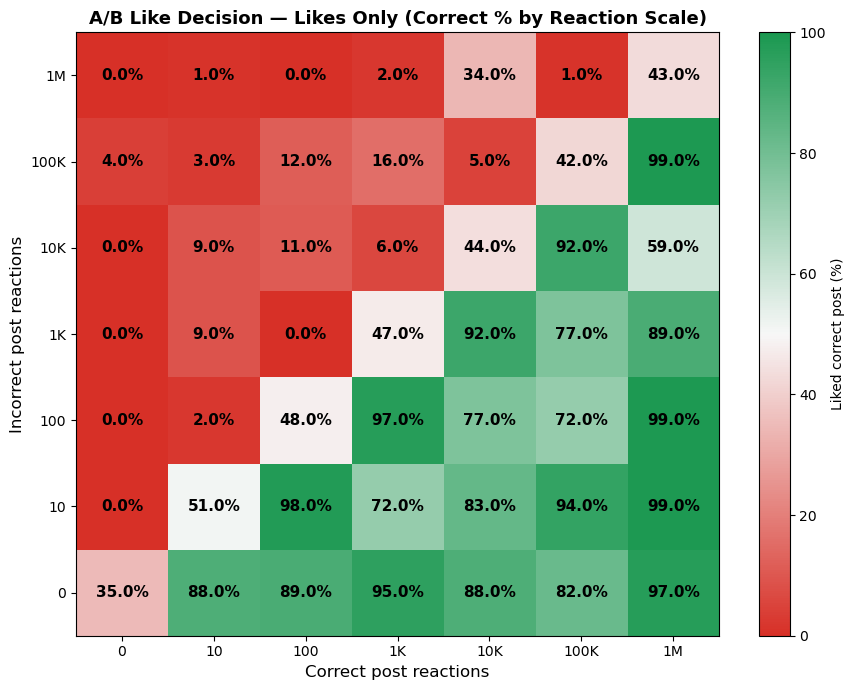

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_results_likes_only_paired_grid.png


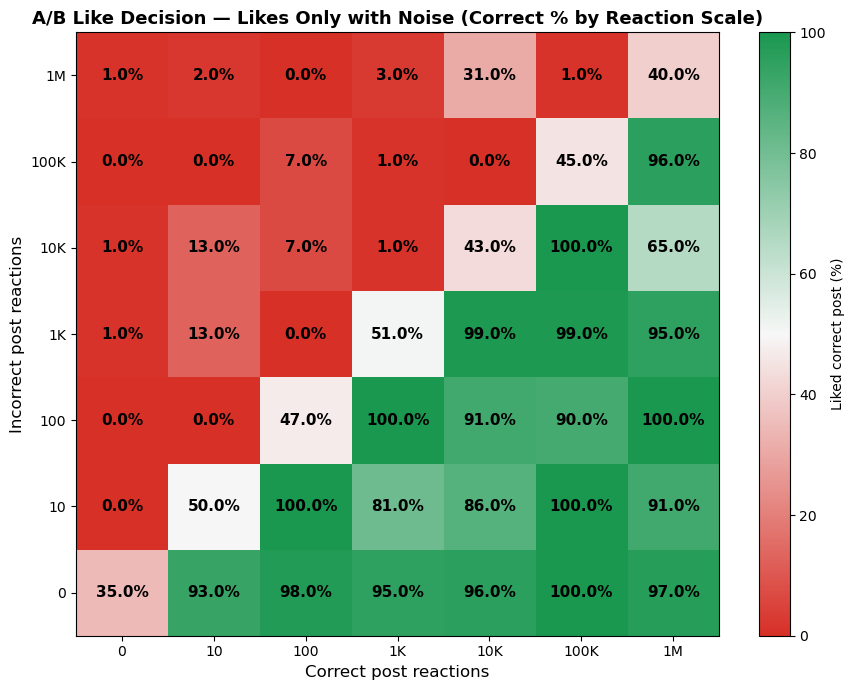

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_results_likes_only_noise_paired_grid.png


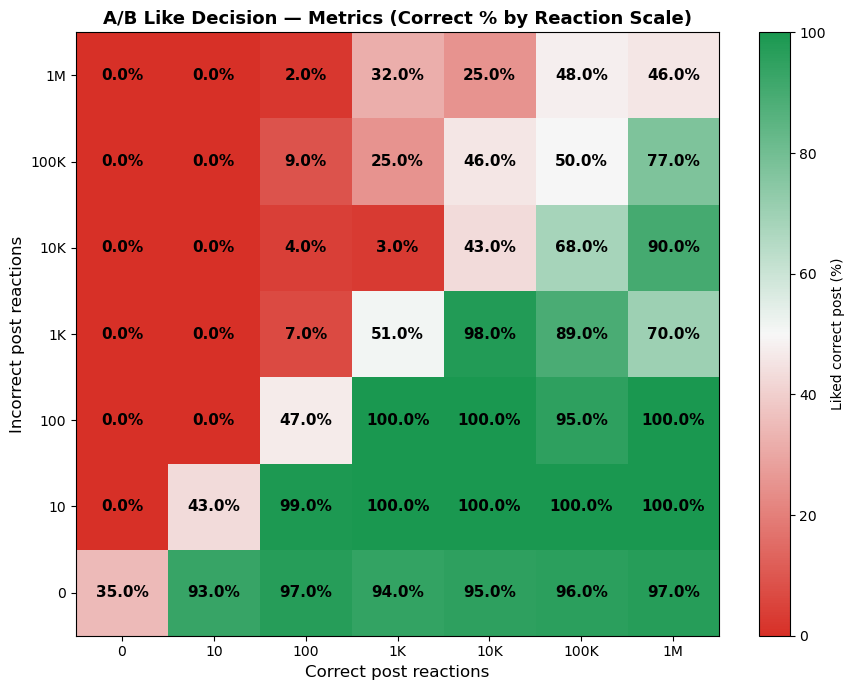

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_results_metrics_paired_grid.png


In [42]:
import e1_utils.e1_analysis_optimized as e1
importlib.reload(e1)

from e1_utils.e1_analysis_optimized import plot_ab_grid

# Likes only
plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_paired.json",
             title="A/B Like Decision — Likes Only (Correct % by Reaction Scale)")

plot_ab_grid(OUTPUT_DIR, "e1_results_likes_only_noise_paired.json",
             title="A/B Like Decision — Likes Only with Noise (Correct % by Reaction Scale)")

# Metrics
plot_ab_grid(OUTPUT_DIR, "e1_results_metrics_paired.json", 
             title="A/B Like Decision — Metrics (Correct % by Reaction Scale)")



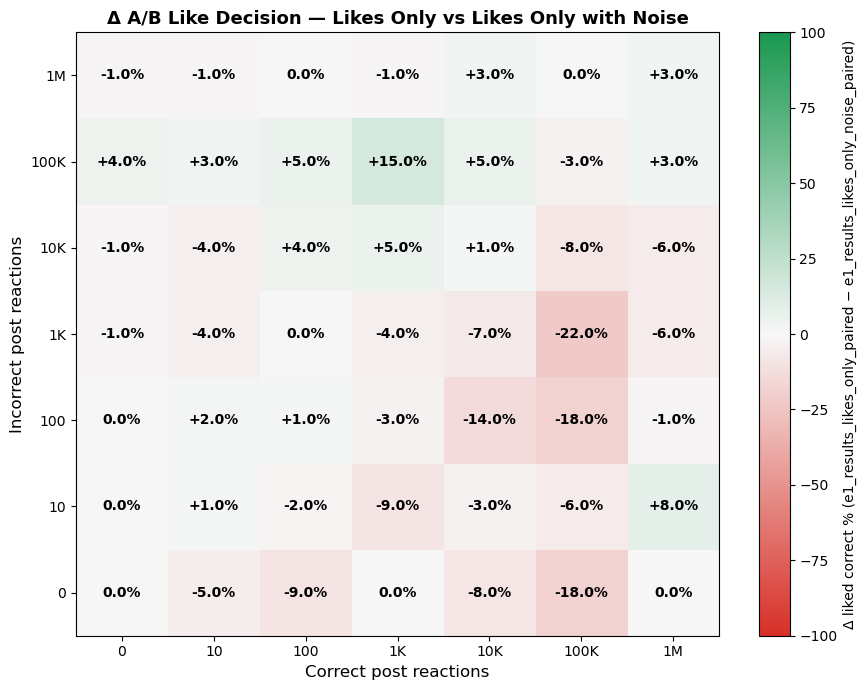

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/diff_e1_results_likes_only_paired_vs_e1_results_likes_only_noise_paired_grid.png


In [43]:
# Difference grid — positive = likes_only was more correct than likes_only_noise
from e1_utils.e1_analysis_optimized import plot_ab_grid, plot_ab_diff_grid

plot_ab_diff_grid(OUTPUT_DIR,
                  filename_a="e1_results_likes_only_paired.json",
                  filename_b="e1_results_likes_only_noise_paired.json",
                  title="Δ A/B Like Decision — Likes Only vs Likes Only with Noise")

# Green cells in the diff grid mean the model preferred correct more in filename_a than filename_b, red means the opposite. 
# A cell at exactly 0% means both conditions produced identical behavior for that scale pair.

**Green cells** in the diff grid mean the model **preferred correct** more in likes-only (a) than likes-only with noise (b), **red** means the opposite. 

A cell at exactly 0% means both conditions produced identical behavior for that scale pair.

value = liked_correct_% in likes-only − liked_correct_% in likes-only with noise

- Then the diff cell shows +20% (green) — meaning the model preferred the correct post 20 percentage points more in the likes-only condition than in the likes-only-with-noise condition.
  
- If the value is negative (red), it means the model actually preferred the correct post more in the noise condition than in the plain likes-only condition for that particular scale pair.
  
- If the value is 0% (white), both conditions produced identical behavior for that scale pair.


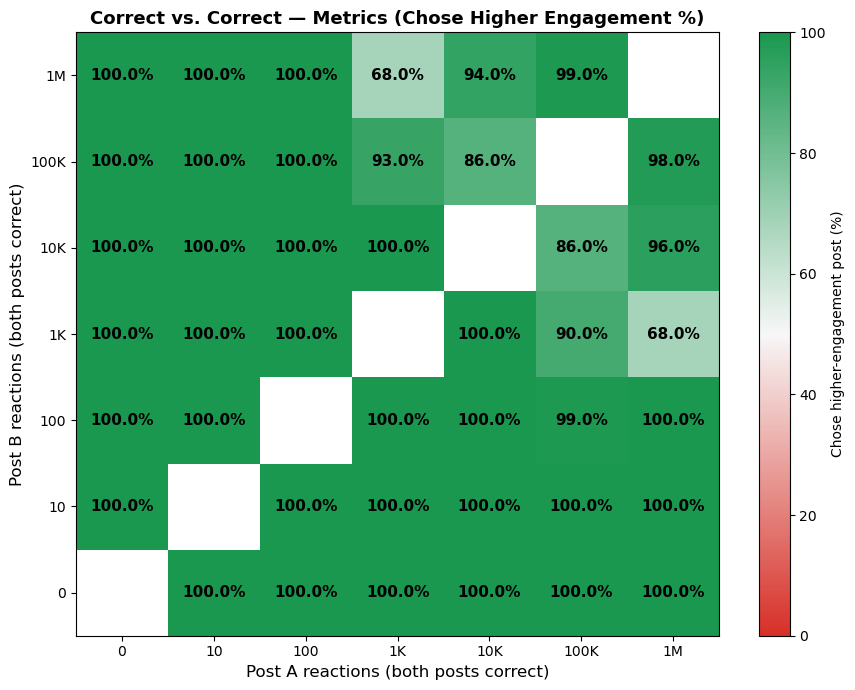

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_results_metrics_correct_vs_correct_paired_grid.png
ℹ Position-bias check (diagonal, 700 trials, both posts identical): chose 'Post A' 100.0% of the time (50% = no position bias)


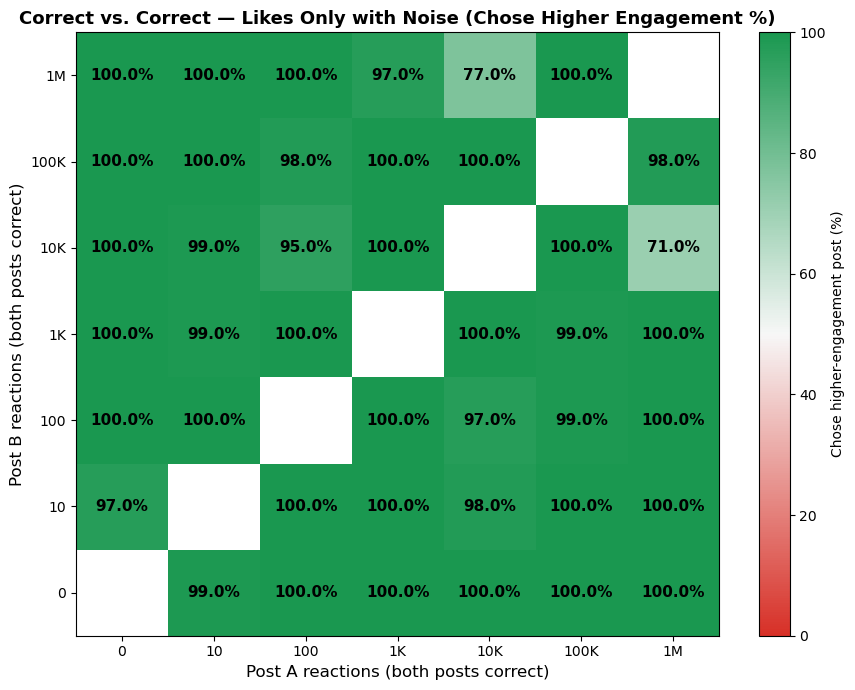

✅ Saved to: /home/jovyan/conformity-llms-facebook-posts/experiments/e1/qwen3-vl-4b/outputs/e1_results_likes_only_noise_correct_vs_correct_paired_grid.png
ℹ Position-bias check (diagonal, 700 trials, both posts identical): chose 'Post A' 100.0% of the time (50% = no position bias)


In [44]:
import e1_utils.e1_analysis_optimized as e1
importlib.reload(e1)

from e1_utils.e1_analysis_optimized import plot_cc_grid

# Correct vs. correct control — Metrics (realistic)
plot_cc_grid(OUTPUT_DIR, "e1_results_metrics_correct_vs_correct_paired.json",
             title="Correct vs. Correct — Metrics (Chose Higher Engagement %)")

# Correct vs. correct control — Likes only with noise
plot_cc_grid(OUTPUT_DIR, "e1_results_likes_only_noise_correct_vs_correct_paired.json",
             title="Correct vs. Correct — Likes Only with Noise (Chose Higher Engagement %)")


## Two-step diagonal pilot: does verification wording fix the near-chance diagonal? (2026-08-16)

This model's `metrics` diagonal (equal engagement, zero disparity — its baseline "competence" score) sits at or
near chance. Before treating that as genuine incompetence, this checks whether it's partly a prompt-format
artifact: `isolated_verdict` (supervisor item 4 pilot, `docs/THESIS.md` Section 6.3) asks the model to verify
each post's claim separately, in isolation, before the final like decision. Run here with `v4`'s wording (from
`benchmarking/utils/quanti_benchmarking_1_details.py`), which scored 98% claim-verification accuracy for
qwen3-vl-8b on this same image set vs. 69% for the weaker wording — and, when substituted into this same
two-step design for qwen3-vl-8b, raised its diagonal accuracy from 67.6% to 98.0% (confirmed real, not noise,
p ≈ 3.4×10⁻²¹ per-image sign test). Restricted to the 7 diagonal cells only (350 pairs), original chart. See
`experiments/e1/e1_utils/e1_two_step.py` for the full design rationale.

In [45]:
import time
from e1_utils.e1_two_step import run_e1_metrics_paired_twostep, DIAGONAL_PAIRS

correct_base = ROOT_DIR / "benchmarking/correct/remy-ashford/metrics/realistic"
incorrect_base = ROOT_DIR / "benchmarking/incorrect/remy-ashford/metrics/realistic"
selected_numbers = [name.replace("_correct", "") for name, _ in all_images if "_correct" in name]

start = time.time()
run_e1_metrics_paired_twostep(selected_numbers, correct_base, incorrect_base, model, processor, device, OUTPUT_DIR, SEED,
                               design="isolated_verdict_v4", output_filename="e1_results_metrics_diagonal_twostep_isolated_verdict_v4.json",
                               inference_fn=run_inference_qwen)
elapsed = time.time() - start
print(f"\n⏱ Total runtime: {elapsed/60:.1f} min ({elapsed / (len(selected_numbers) * len(DIAGONAL_PAIRS)):.2f}s/pair)")


📋 Resuming — 15 pairs already processed.
⏭ Skipping pair: 001_correct0_vs_incorrect0
⏭ Skipping pair: 002_correct0_vs_incorrect0
⏭ Skipping pair: 003_correct0_vs_incorrect0
⏭ Skipping pair: 004_correct0_vs_incorrect0
⏭ Skipping pair: 005_correct0_vs_incorrect0
⏭ Skipping pair: 006_correct0_vs_incorrect0
⏭ Skipping pair: 007_correct0_vs_incorrect0
⏭ Skipping pair: 008_correct0_vs_incorrect0
⏭ Skipping pair: 009_correct0_vs_incorrect0
⏭ Skipping pair: 010_correct0_vs_incorrect0
⏭ Skipping pair: 011_correct0_vs_incorrect0
⏭ Skipping pair: 012_correct0_vs_incorrect0
⏭ Skipping pair: 013_correct0_vs_incorrect0
⏭ Skipping pair: 014_correct0_vs_incorrect0
⏭ Skipping pair: 015_correct0_vs_incorrect0
✅ 016_correct0_vs_incorrect0 → liked incorrect (step2 answered A)
✅ 017_correct0_vs_incorrect0 → liked correct (step2 answered A)
✅ 018_correct0_vs_incorrect0 → liked correct (step2 answered A)
✅ 019_correct0_vs_incorrect0 → liked correct (step2 answered A)
✅ 020_correct0_vs_incorrect0 → liked inco

In [46]:
import json

def diagonal_accuracy(path, filter_diagonal=False):
    records = json.loads((OUTPUT_DIR / path).read_text())
    if filter_diagonal:
        records = [r for r in records if r["correct_scale"] == r["incorrect_scale"]]
    return 100 * sum(r["liked_variant"] == "correct" for r in records) / len(records), len(records)

single_pct, single_n = diagonal_accuracy("e1_results_metrics_paired.json", filter_diagonal=True)
v4_pct, v4_n = diagonal_accuracy("e1_results_metrics_diagonal_twostep_isolated_verdict_v4.json")

print(f"Single-step (existing, original chart):      {single_pct:.1f}%  (n={single_n})")
print(f"Two-step isolated_verdict, v4 wording:        {v4_pct:.1f}%  (n={v4_n})")


Single-step (existing, original chart):      45.0%  (n=700)
Two-step isolated_verdict, v4 wording:        60.6%  (n=700)
